# 🧪 Laboratorio de algoritmos de búsqueda
**BFS · DFS · UCS · A\***  
**Alumna:** Kelly Jocelyn Arámburo González

**Problemas:** 8-Puzzle · Mapa de Rumania · Knapsack 0/1 (opcional)

---

Este notebook implementa los cuatro algoritmos de búsqueda solicitados, los aplica a las mismas instancias para permitir comparaciones justas, registra las métricas relevantes y exporta los resultados a un archivo `.xlsx`.

**Nota sobre el 8-Puzzle.** La matriz dada en la consigna `[[0,1,2],[3,4,5],[7,6,8]]` tiene **1 inversión** (impar), por lo que **no es resoluble** con el objetivo estándar `[[1,2,3],[4,5,6],[7,8,0]]` (0 inversiones, par). Como el profesor indicó que documentáramos nuestro objetivo, se usa una instancia con paridad par: `[[1,2,3],[4,8,5],[7,6,0]]` (4 inversiones), resoluble en 4 movimientos con el objetivo estándar.

In [3]:
import copy, io, json, time, tracemalloc, platform, hashlib, heapq
from pathlib import Path
from collections import deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import ipywidgets as widgets

plt.rcParams.update({'figure.figsize': (9, 5),
                     'axes.spines.top': False,
                     'axes.spines.right': False})

ENTORNO = {'python': platform.python_version(),
           'numpy': np.__version__,
           'pandas': pd.__version__}
display(ENTORNO)

{'python': '3.13.15', 'numpy': '2.1.3', 'pandas': '2.2.3'}

## 1. 📦 Datos de entrada

- **Knapsack:** primera fila de `knapsack_5_items.csv` del dataset `warcoder/knapsack-problem`.
- **Rumania:** diccionarios `ROADS`, `LOCATIONS` y `NAMES` (los `ROADS` se simetrizan en la modelación porque vienen con una sola dirección).
- **8-Puzzle:** matriz inicial con paridad par, compatible con el objetivo estándar.

In [4]:
%pip -q install "kagglehub[pandas-datasets]" >/dev/null 2>&1

import kagglehub
from kagglehub import KaggleDatasetAdapter

try:
    df = kagglehub.load_dataset(
        KaggleDatasetAdapter.PANDAS,
        "warcoder/knapsack-problem",
        "knapsack_5_items.csv",
    )
    datos_knapsack = df.loc[0].to_dict()
    HUELLA_DATOS = hashlib.sha256(
        json.dumps(datos_knapsack, sort_keys=True, ensure_ascii=False).encode()
    ).hexdigest()

    def leer_vector(texto):
        return np.array([int(x) for x in texto.strip().strip('[]').split()], dtype=int)

    ENTRADA_KNAPSACK = {
        'Weights': leer_vector(datos_knapsack['Weights']),
        'Prices': leer_vector(datos_knapsack['Prices']),
        'Capacity': int(datos_knapsack['Capacity']),
    }
    print('Knapsack cargado correctamente.')
    display(df.loc[[0], ['Weights', 'Prices', 'Capacity']])
    print('Huella SHA-256:', HUELLA_DATOS)
    print('Entrada:', ENTRADA_KNAPSACK)

except Exception as e:
    print('No se pudo cargar desde Kaggle (sin conexión). Usando fallback.')
    HUELLA_DATOS = 'fallback-local'
    ENTRADA_KNAPSACK = {
        'Weights': np.array([46, 40, 42, 38, 10]),
        'Prices':  np.array([12, 19, 19, 15,  8]),
        'Capacity': 40,
    }
    print('Entrada (fallback):', ENTRADA_KNAPSACK)

/tmp/ipykernel_4231/2634303506.py:7: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 573k/573k [00:00<00:00, 2.06MB/s]

Knapsack cargado correctamente.


,Weights,Prices,Capacity
0,[46 40 42 38 10],[12 19 19 15 8],40


Huella SHA-256: f33b8c367c8023ffc0c83019e4950f625a5cb56005849597c28be0158efe2891
Entrada: {'Weights': array([46, 40, 42, 38, 10]), 'Prices': array([12, 19, 19, 15,  8]), 'Capacity': 40}


In [5]:
ROADS = dict(
    A=dict(Z=75, S=140, T=118), B=dict(U=85, P=101, G=90, F=211),
    C=dict(D=120, R=146, P=138), D=dict(M=75), E=dict(H=86),
    F=dict(S=99), H=dict(U=98), I=dict(V=92, N=87),
    L=dict(T=111, M=70), O=dict(Z=71, S=151), P=dict(R=97),
    R=dict(S=80), U=dict(V=142))

LOCATIONS = dict(
    A=(91,492), B=(400,327), C=(253,288), D=(165,299),
    E=(562,293), F=(305,449), G=(375,270), H=(534,350),
    I=(473,506), L=(165,379), M=(168,339), N=(406,537),
    O=(131,571), P=(320,368), R=(233,410), S=(207,457),
    T=(94,410), U=(456,350), V=(509,444), Z=(108,531))

NAMES = dict(A='Arad', B='Bucarest', C='Craiova', D='Drobeta',
             E='Eforie', F='Fagaras', G='Giurgiu', H='Hirsova', I='Iasi',
             L='Lugoj', M='Mehadia', N='Neamt', O='Oradea', P='Pitesti',
             R='Rimnicu Vilcea', S='Sibiu', T='Timisoara', U='Urziceni',
             V='Vaslui', Z='Zerind')

print(f'Rumania: {len(ROADS)} nodos, {sum(len(v) for v in ROADS.values())} aristas declaradas.')

Rumania: 13 nodos, 23 aristas declaradas.


In [6]:
# Instancia resoluble con el objetivo estándar (4 inversiones, par).
PUZZLE_INICIAL  = np.array([[1, 2, 3],
                             [4, 8, 5],
                             [7, 6, 0]])

PUZZLE_OBJETIVO = (1, 2, 3, 4, 5, 6, 7, 8, 0)

# Verificación de solubilidad (paridad de inversiones)
def _contar_inversiones(tupla):
    seq = [x for x in tupla if x != 0]
    inv = 0
    for i in range(len(seq)):
        for j in range(i + 1, len(seq)):
            if seq[i] > seq[j]:
                inv += 1
    return inv

_ini_t = tuple(int(x) for x in PUZZLE_INICIAL.flatten())
print('Inversiones (inicial):', _contar_inversiones(_ini_t))
print('Inversiones (objetivo):', _contar_inversiones(PUZZLE_OBJETIVO))
print('Solubles:', (_contar_inversiones(_ini_t) % 2) == (_contar_inversiones(PUZZLE_OBJETIVO) % 2))

Inversiones (inicial): 4
Inversiones (objetivo): 0
Solubles: True


## 2. 🎨 Utilidades de visualización
Funciones de la plantilla


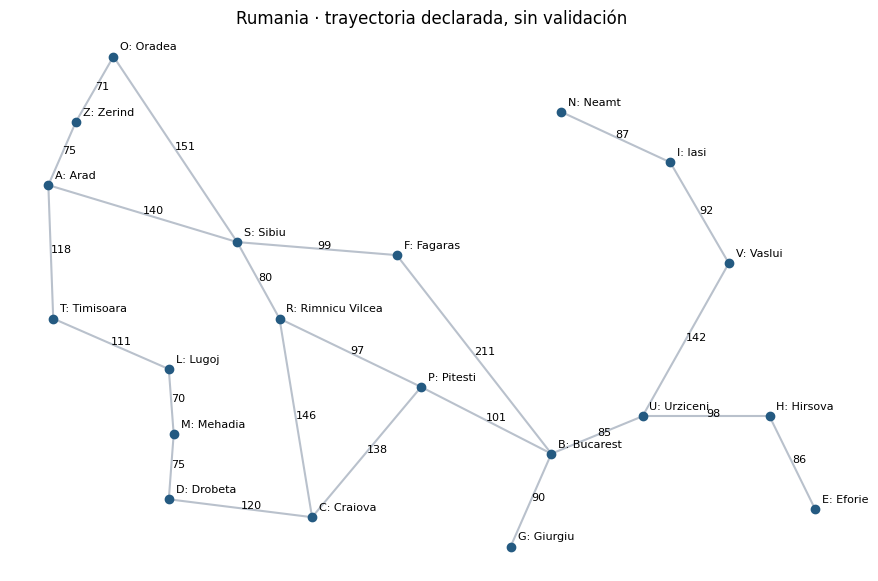

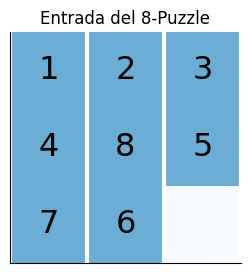

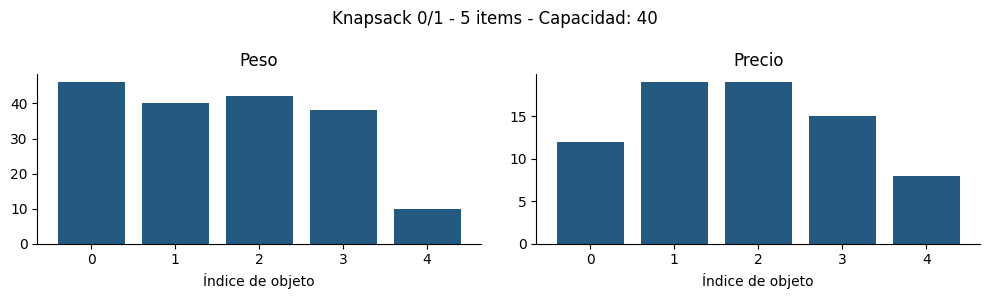

In [7]:
def ver_rumania(ruta=None):
    fig, ax = plt.subplots(figsize=(11, 7))
    for a, destinos in ROADS.items():
        for b, distancia in destinos.items():
            x, y = LOCATIONS[a], LOCATIONS[b]
            ax.plot([x[0], y[0]], [x[1], y[1]], color='#b9c1cc', zorder=1)
            ax.text((x[0]+y[0])/2, (x[1]+y[1])/2, str(distancia), fontsize=8)
    for c, (x, y) in LOCATIONS.items():
        ax.scatter(x, y, color='#245a81', zorder=3)
        ax.annotate(f'{c}: {NAMES[c]}', (x, y), xytext=(5, 5),
                    textcoords='offset points', fontsize=8)
    if ruta is not None and len(ruta):
        puntos = np.array([LOCATIONS[c] for c in ruta])
        ax.plot(puntos[:, 0], puntos[:, 1], color='#e47727', linewidth=3, zorder=2)
    ax.set_title('Rumania · trayectoria declarada, sin validación')
    ax.set_aspect('equal'); ax.axis('off'); plt.show()

def ver_tablero(tablero, titulo='Tablero'):
    a = np.asarray(tablero)
    if a.shape != (3, 3):
        raise ValueError('La visualización requiere una matriz 3×3.')
    fig, ax = plt.subplots(figsize=(3, 3))
    ax.imshow(np.where(a == 0, 0, 1), cmap='Blues', vmin=0, vmax=2)
    for (i, j), valor in np.ndenumerate(a):
        if valor != 0:
            ax.text(j, i, str(valor), ha='center', va='center', fontsize=23)
    ax.set_xticks(np.arange(-.5, 3, 1), minor=True)
    ax.set_yticks(np.arange(-.5, 3, 1), minor=True)
    ax.grid(which='minor', color='white', linewidth=3)
    ax.tick_params(which='both', bottom=False, left=False,
                   labelbottom=False, labelleft=False)
    ax.set_title(titulo); plt.show()

def explorar_tableros(tableros):
    if len(tableros) == 0:
        print('No hay tableros registrados.'); return
    return widgets.interact(lambda paso: ver_tablero(tableros[paso], f'Paso {paso}'),
                            paso=widgets.IntSlider(min=0, max=len(tableros)-1, value=0))

def ver_knapsack(datos, seleccion=None):
    pesos, precios = np.asarray(datos['Weights']), np.asarray(datos['Prices'])
    ids = np.arange(len(pesos))
    elegidos = set([] if seleccion is None else seleccion)
    if not elegidos.issubset(set(ids)):
        raise ValueError('Índice de objeto fuera del dataset.')
    colores = ['#e47727' if i in elegidos else '#245a81' for i in ids]
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    for ax, valores, nombre in zip(axes, [pesos, precios], ['Peso', 'Precio']):
        ax.bar(ids, valores, color=colores)
        ax.set(title=nombre, xlabel='Índice de objeto', xticks=ids)
    fig.suptitle(f"Knapsack 0/1 - 5 items - Capacidad: {datos['Capacity']}")
    plt.tight_layout(); plt.show()

# Vista previa
ver_rumania()
ver_tablero(PUZZLE_INICIAL, 'Entrada del 8-Puzzle')
ver_knapsack(ENTRADA_KNAPSACK)

## 3. ✍️ Modelación de cada problema como búsqueda

| Decisión | Rumania | 8-Puzzle | Knapsack 0/1 |
|---|---|---|---|
| **Estado** | Ciudad actual (código) | Tupla de 9 enteros, 0 = hueco | `(i, peso, valor, selección)` |
| **Estado inicial** | `A` (Arad) | `(1,2,3,4,8,5,7,6,0)` | `(0, 0, 0, [])` |
| **Estado objetivo** | `B` (Bucarest) | `(1,2,3,4,5,6,7,8,0)` | Cualquier nodo con `i == n` |
| **Acciones** | Viajar a ciudad adyacente | Mover 0 en U/D/L/R | Incluir o excluir ítem `i` |
| **Sucesores** | Vecinos en `ROADS` simetrizado | Intercambiar 0 con ficha adyacente | Ambos branches (tomar / no tomar) |
| **Costo** | Distancia km | 1 por movimiento | `-valor` (minimizar ⇔ maximizar) |
| **Criterio de solución** | `ciudad == B` | `estado == objetivo` | `i == n`; se guarda el mejor valor |
| **Frontera** | `deque` / lista / `heapq` | `deque` / lista / `heapq` | `deque` / lista / `heapq` |
| **Visitados** | `set` (BFS/DFS) · `dict` (UCS/A*) | `set` (BFS/DFS) · `dict` (UCS/A*) | `set` por `(i, peso)` |

**Heurísticas**

| Problema | Heurística | Fórmula | ¿Admisible? |
|---|---|---|---|
| Rumania | Distancia euclidiana a Bucarest | `√((x−xB)² + (y−yB)²)` | Sí: la línea recta nunca supera la distancia por carretera |
| 8-Puzzle | Distancia Manhattan | `Σ |fila_ficha − fila_meta| + |col_ficha − col_meta|` | Sí: cada movimiento reduce la distancia de una ficha a lo más en 1 |
| Knapsack | Cota fraccionaria | Valor óptimo del problema relajado (permitiendo fracciones) | Sí (para maximizar): cota superior del óptimo entero |

## 4. 🧩 Contrato del laboratorio
Cada función recibe `(datos, configuracion)` y devuelve un diccionario con `estado ∈ {exito, sin_solucion, limite}` y las métricas: `costo`, `valor_objetivo`, `expandidos`, `generados`, `frontera_max`, `profundidad`, `notas`, `visual`.

In [8]:
# =====================================================================
#  IMPLEMENTACIÓN DE LOS 4 ALGORITMOS PARA LOS 3 PROBLEMAS
# =====================================================================


# ---------------------------------------------------------------------
# Función auxiliar que crea el diccionario de salida con valores por
# defecto. Todas las funciones de búsqueda devolverán un dict,
# para cumplir el "contrato" del laboratorio del profesor.
# ---------------------------------------------------------------------
def _res(estado='exito', **kw):
    base = {
        'estado': estado,          # 'exito' | 'sin_solucion' | 'limite'
        'costo': None,             # costo del camino encontrado
        'valor_objetivo': None,    # solo se usa en Knapsack (valor de la mochila)
        'expandidos': None,        # nodos sacados de la frontera
        'generados': None,         # nodos creados como sucesores
        'frontera_max': None,      # tamaño máximo que alcanzó la frontera
        'profundidad': None,       # longitud del camino correcto
        'notas': '',               # mensajes opcionales
        'visual': {}               # datos para dibujar (ruta, tableros, selección)
    }
    base.update(kw)                # sobreescribe con lo que le pases
    return base

# ============================ RUMANIA ================================
def _grafo_rumania(datos):
    g = {}
    for a, vec in datos['ROADS'].items():
        g.setdefault(a, {})                     # asegura que 'a' exista
        for b, d in vec.items():
            g.setdefault(b, {})                 # asegura que 'b' exista
            g[a][b] = d                         # dirección a → b
            g[b][a] = d                         # dirección b → a
    return g

#Recibe el destino y devuelve una función h(ciudad) que calcula la distancia usando A*.
def _h_rumania(datos, destino):
    loc = datos['LOCATIONS']                    # {A: (91,492)...}
    xd, yd = loc[destino]                       # coordenadas del destino Bucarest
    def h(c):
        xc, yc = loc[c]                         # coordenadas de la ciudad actual
        # Fórmula de distancia euclidiana: √((x1−x2)² + (y1−y2)²)
        return ((xc - xd) ** 2 + (yc - yd) ** 2) ** 0.5
    return h

#============ Busqueda por anchura para Rumania==========================
# Explora por niveles y ve el camino con menos aristas,pero NO el de menor costo.

def _rumania_bfs(datos, config):
    g = _grafo_rumania(datos)
    origen, destino = config['origen'], config['destino']
    lim_exp = config.get('limite_expandidos', 10**6)            # corte por nodos
    lim_s   = config.get('limite_s', 10)                        # corte por tiempo
    t0 = time.perf_counter()                                    # timepo

    # Cada elemento es (ciudad, camino, costo acumulado)
    fr = deque([(origen, [origen], 0)])
    visit = {origen}                                          # ciudades ya vistas
    exp = gen = 1                                             # contador
    fmax = 1                                                  # tamaño max de la frontera

    while fr:
        # Verifica si se agotó algún límite antes de expandir
        if exp > lim_exp or time.perf_counter() - t0 > lim_s:
            return _res('limite', expandidos=exp, generados=gen, frontera_max=fmax)

        # Saca el primero de la cola
        ciudad, camino, costo = fr.popleft()
        exp += 1

        # ¿Llegamos al destino?
        if ciudad == destino:
            return _res(costo=costo, expandidos=exp, generados=gen,
                        frontera_max=fmax, profundidad=len(camino)-1,
                        visual={'ruta': camino})

        # Genera sucesores ordenados alfabéticamente
        for v in sorted(g[ciudad]):
            if v not in visit:         # evita ciclos
                visit.add(v)
                gen += 1               # contamos
                fr.append((v, camino + [v], costo + g[ciudad][v]))
        fmax = max(fmax, len(fr))
    return _res('sin_solucion', expandidos=exp, generados=gen, frontera_max=fmax)

# ================Busqueda de profundidad para Rumania=================
def _rumania_dfs(datos, config):
    g = _grafo_rumania(datos)
    origen, destino = config['origen'], config['destino']
    lim_exp = config.get('limite_expandidos', 10**6)
    lim_s   = config.get('limite_s', 10)
    t0 = time.perf_counter()

    # Pila: cada elemento lleva (ciudad, camino, costo, set de visitados en la rama)
    fr = [(origen, [origen], 0, {origen})]
    exp = gen = 0
    fmax = 1

    while fr:
        if exp > lim_exp or time.perf_counter() - t0 > lim_s:
            return _res('limite', expandidos=exp, generados=gen, frontera_max=fmax)

        # Saca el último
        ciudad, camino, costo, visto = fr.pop()
        exp += 1
        if ciudad == destino:
            return _res(costo=costo, expandidos=exp, generados=gen,
                        frontera_max=fmax, profundidad=len(camino)-1,
                        visual={'ruta': camino})

        # Se empuja en orden inverso para que el primero  salga primero
        for v in sorted(g[ciudad], reverse=True):
            if v not in visto:
                gen += 1
                fr.append((v, camino + [v], costo + g[ciudad][v], visto | {v}))
        fmax = max(fmax, len(fr))
    return _res('sin_solucion', expandidos=exp, generados=gen, frontera_max=fmax)

# ================Busqueda de costo uniforme para Rumania====================
#Garantiza la ruta más barata cuando todos los costos son positivos.
def _rumania_ucs(datos, config):
    g = _grafo_rumania(datos)
    origen, destino = config['origen'], config['destino']
    lim_exp = config.get('limite_expandidos', 10**6)
    lim_s   = config.get('limite_s', 10)
    t0 = time.perf_counter()
    fr = [(0, 0, origen, [origen])]
    mejor = {origen: 0}                  # mejor costo conocido por ciudad
    cont = 0
    exp = gen = 0
    fmax = 1

    while fr:
        if exp > lim_exp or time.perf_counter() - t0 > lim_s:
            return _res('limite', expandidos=exp, generados=gen, frontera_max=fmax)

        # Saca el de menor costo acumulado
        costo, _, ciudad, camino = heapq.heappop(fr)
        exp += 1
        if ciudad == destino:
            return _res(costo=costo, expandidos=exp, generados=gen,
                        frontera_max=fmax, profundidad=len(camino)-1,
                        visual={'ruta': camino})
        for v, d in g[ciudad].items():
            ng = costo + d        # nuevo costo acumulado
            # Solo expande si mejora el mejor costo conocido de v
            if v not in mejor or ng < mejor[v]:
                mejor[v] = ng
                cont += 1
                gen += 1
                heapq.heappush(fr, (ng, cont, v, camino + [v]))
        fmax = max(fmax, len(fr))
    return _res('sin_solucion', expandidos=exp, generados=gen, frontera_max=fmax)

# ==================Heuristica(A*) para Rumania======================
def _rumania_astar(datos, config):
    g = _grafo_rumania(datos)
    h = _h_rumania(datos, config['destino'])        # función A
    origen, destino = config['origen'], config['destino']
    lim_exp = config.get('limite_expandidos', 10**6)
    lim_s   = config.get('limite_s', 10)
    t0 = time.perf_counter()

    # Frontera ordenada por f = g + h. Elemento = (f, g, contador, ciudad, camino)
    fr = [(h(origen), 0, 0, origen, [origen])]
    mejor = {origen: 0}
    cont = 0
    exp = gen = 0
    fmax = 1
    while fr:
        if exp > lim_exp or time.perf_counter() - t0 > lim_s:
            return _res('limite', expandidos=exp, generados=gen, frontera_max=fmax)

        # Saca el de menor f
        _, costo, _, ciudad, camino = heapq.heappop(fr)
        exp += 1
        if ciudad == destino:
            return _res(costo=costo, expandidos=exp, generados=gen,
                        frontera_max=fmax, profundidad=len(camino)-1,
                        visual={'ruta': camino})

        for v, d in g[ciudad].items():
            ng = costo + d
            if v not in mejor or ng < mejor[v]:
                mejor[v] = ng
                cont += 1
                gen += 1
                # Prioridad = g + h
                heapq.heappush(fr, (ng + h(v), ng, cont, v, camino + [v]))
        fmax = max(fmax, len(fr))
    return _res('sin_solucion', expandidos=exp, generados=gen, frontera_max=fmax)

# =========================== 8-PUZZLE ================================
# Convierte la matriz 3×3 a una tupla plana de 9 elementos.
def _puzzle_vec(m):
    return tuple(int(x) for x in np.asarray(m).flatten())

def _puzzle_sucesores(estado):
    i = estado.index(0)                   # posición del hueco
    f, c = divmod(i, 3)                  # fila, columna del hueco
    # Prueba las 4 direcciones
    for _, df, dc in (('ARRIBA', -1, 0), ('ABAJO', 1, 0), ('IZQUIERDA', 0, -1), ('DERECHA', 0, 1)):
        nf, nc = f + df, c + dc                     # nueva posición
        if 0 <= nf < 3 and 0 <= nc < 3:
            j = nf * 3 + nc                         # índice en la tupla plana
            nuevo = list(estado)                    # copia mutable
            nuevo[i], nuevo[j] = nuevo[j], nuevo[i] # intercambia hueco y ficha
            yield tuple(nuevo)                      # devuelve la nueva tupla

# ================Heurística para el 8-Puzzle.==========================0

def _h_puzzle(estado, objetivo):
    pos = {v: k for k, v in enumerate(objetivo)}
    d = 0
    for i, v in enumerate(estado):
        if v == 0:             # ignora el hueco
            continue
        j = pos[v]          # posición meta de la ficha
        # |fila_actual - fila_meta| + |col_actual - col_meta|
        d += abs(i // 3 - j // 3) + abs(i % 3 - j % 3)
    return d

# Dibujar la animación paso a paso con `explorar_tableros()`.
def _camino_a_tableros(camino):
    return [np.array(e).reshape(3, 3) for e in camino]

# =========Busqueda por anchura para el 8-Puzzle.============
def _puzzle_bfs(datos, config):
    ini  = _puzzle_vec(datos)                  # estado inicial
    meta = tuple(config['objetivo'])            # estado objetivo
    lim_exp = config.get('limite_expandidos', 200000)
    lim_s   = config.get('limite_s', 10)
    t0 = time.perf_counter()
    fr = deque([(ini, [ini])])
    visit = {ini}
    exp = gen = 1
    fmax = 1

    while fr:
        if exp > lim_exp or time.perf_counter() - t0 > lim_s:
            return _res('limite', expandidos=exp, generados=gen, frontera_max=fmax)
        est, camino = fr.popleft()
        exp += 1
        if est == meta:
            return _res(costo=len(camino)-1,        # costo = movimientos
                        expandidos=exp, generados=gen, frontera_max=fmax,
                        profundidad=len(camino)-1,
                        visual={'tableros': _camino_a_tableros(camino)})
        for nxt in _puzzle_sucesores(est):
            if nxt not in visit:
                visit.add(nxt)
                gen += 1
                fr.append((nxt, camino + [nxt]))
        fmax = max(fmax, len(fr))
    return _res('sin_solucion', expandidos=exp, generados=gen, frontera_max=fmax)

# ==============Busqueda por profundidad ara el 8-Puzzle=============
# Sin límite puede caer en caminos infinitos para evitarlo se corta cuando d >= prof_max.
def _puzzle_dfs(datos, config):
    ini  = _puzzle_vec(datos)
    meta = tuple(config['objetivo'])
    lim_exp  = config.get('limite_expandidos', 200000)
    lim_s    = config.get('limite_s', 10)
    prof_max = config.get('limite_profundidad', 25)     #corte de profundidad
    t0 = time.perf_counter()
  # Pila: (estado, camino, profundidad, visitados-en-rama)
    fr = [(ini, [ini], 0, {ini})]
    exp = gen = 0
    fmax = 1
    while fr:
        if exp > lim_exp or time.perf_counter() - t0 > lim_s:
            return _res('limite', expandidos=exp, generados=gen,
                        frontera_max=fmax, notas='límite alcanzado')
        est, camino, d, visto = fr.pop()
        exp += 1
        if est == meta:
            return _res(costo=len(camino)-1, expandidos=exp, generados=gen,
                        frontera_max=fmax, profundidad=len(camino)-1,
                        visual={'tableros': _camino_a_tableros(camino)})

        if d >= prof_max:           # si llegó al tope, no expande
            continue
        for nxt in _puzzle_sucesores(est):
            if nxt not in visto:
                gen += 1
                fr.append((nxt, camino + [nxt], d + 1, visto | {nxt}))
        fmax = max(fmax, len(fr))
    return _res('sin_solucion', expandidos=exp, generados=gen, frontera_max=fmax)


# ============Busqueda de costo uniforme para el 8-Puzzle.=========0
def _puzzle_ucs(datos, config):
    ini  = _puzzle_vec(datos)
    meta = tuple(config['objetivo'])
    lim_exp = config.get('limite_expandidos', 200000)
    lim_s   = config.get('limite_s', 10)
    t0 = time.perf_counter()

    fr = [(0, 0, ini, [ini])]      # (g, contador, estado, camino)
    mejor = {ini: 0}
    cont = 0
    exp = gen = 0
    fmax = 1

    while fr:
        if exp > lim_exp or time.perf_counter() - t0 > lim_s:
            return _res('limite', expandidos=exp, generados=gen, frontera_max=fmax)
        g, _, est, camino = heapq.heappop(fr)
        exp += 1
        if est == meta:
            return _res(costo=g, expandidos=exp, generados=gen,
                        frontera_max=fmax, profundidad=len(camino)-1,
                        visual={'tableros': _camino_a_tableros(camino)})

        for nxt in _puzzle_sucesores(est):
            ng = g + 1            # cada movimiento cuesta 1
            if nxt not in mejor or ng < mejor[nxt]:
                mejor[nxt] = ng
                cont += 1
                gen += 1
                heapq.heappush(fr, (ng, cont, nxt, camino + [nxt]))
        fmax = max(fmax, len(fr))
    return _res('sin_solucion', expandidos=exp, generados=gen, frontera_max=fmax)


# =============== Heuristica para el 8-Puzzle =======================.
def _puzzle_astar(datos, config):
    ini  = _puzzle_vec(datos)
    meta = tuple(config['objetivo'])
    lim_exp = config.get('limite_expandidos', 200000)
    lim_s   = config.get('limite_s', 10)
    t0 = time.perf_counter()

    # Frontera: (f, g, contador, estado, camino)
    fr = [(_h_puzzle(ini, meta), 0, 0, ini, [ini])]
    mejor = {ini: 0}
    cont = 0
    exp = gen = 0
    fmax = 1

    while fr:
        if exp > lim_exp or time.perf_counter() - t0 > lim_s:
            return _res('limite', expandidos=exp, generados=gen, frontera_max=fmax)
        _, g, _, est, camino = heapq.heappop(fr)
        exp += 1
        if est == meta:
            return _res(costo=g, expandidos=exp, generados=gen,
                        frontera_max=fmax, profundidad=len(camino)-1,
                        visual={'tableros': _camino_a_tableros(camino)})
        for nxt in _puzzle_sucesores(est):
            ng = g + 1
            if nxt not in mejor or ng < mejor[nxt]:
                mejor[nxt] = ng
                cont += 1
                gen += 1
                heapq.heappush(fr, (ng + _h_puzzle(nxt, meta), ng, cont,
                                    nxt, camino + [nxt]))
        fmax = max(fmax, len(fr))
    return _res('sin_solucion', expandidos=exp, generados=gen, frontera_max=fmax)


# =========================== KNAPSACK ================================
def _h_knapsack(datos, idx, cap_rest):
    w, p = datos['Weights'], datos['Prices']
    # Ordena los ítems
    items = sorted([(p[k]/w[k], w[k], p[k]) for k in range(idx, len(w))],
                   reverse=True)
    val, libre = 0.0, cap_rest
    for ratio, wk, pk in items:
        if wk <= libre:                             # cabe entero
            val += pk
            libre -= wk
        elif libre > 0:                             # cabe fracción
            val += ratio * libre
            libre = 0
    return val


# ===================Busqueda por anchura para Knapsack.===================
def _knapsack_bfs(datos, config):
    w, p, cap = datos['Weights'], datos['Prices'], datos['Capacity']
    n = len(w)
    lim_exp = config.get('limite_expandidos', 10**6)
    lim_s   = config.get('limite_s', 10)
    t0 = time.perf_counter()

    # Frontera: (índice, peso acumulado, valor acumulado, selección)
    fr = deque([(0, 0, 0, [])])
    exp = gen = 1
    fmax = 1
    mejor = (0, [])   # (mejor valor o selección)

    while fr:
        if exp > lim_exp or time.perf_counter() - t0 > lim_s:
            return _res('limite', expandidos=exp, generados=gen, frontera_max=fmax)
        i, peso, val, sel = fr.popleft()
        exp += 1
        if i == n:
            if val > mejor[0]:
                mejor = (val, sel)
            continue

        # Rama 1: NO tomar el ítem i
        gen += 1
        fr.append((i + 1, peso, val, sel))

        # Rama 2: SÍ tomar el ítem i (solo si cabe)
        if peso + w[i] <= cap:
            gen += 1
            fr.append((i + 1, peso + w[i], val + p[i], sel + [i]))
        fmax = max(fmax, len(fr))
    return _res(valor_objetivo=int(mejor[0]),
                costo=int(-mejor[0]),      # costo = -valor (minimizar costo = maximizar valor)
                expandidos=exp, generados=gen, frontera_max=fmax, profundidad=n,
                visual={'seleccion': mejor[1]})


# ==============Busqueda de profundidad para Knapsack==================
def _knapsack_dfs(datos, config):
    w, p, cap = datos['Weights'], datos['Prices'], datos['Capacity']
    n = len(w)
    lim_exp = config.get('limite_expandidos', 10**6)
    lim_s   = config.get('limite_s', 10)
    t0 = time.perf_counter()

    fr = [(0, 0, 0, [])]
    exp = gen = 0
    fmax = 1
    mejor = (0, [])

    while fr:
        if exp > lim_exp or time.perf_counter() - t0 > lim_s:
            return _res('limite', expandidos=exp, generados=gen, frontera_max=fmax)
        i, peso, val, sel = fr.pop()
        exp += 1
        if i == n:
            if val > mejor[0]:
                mejor = (val, sel)
            continue

      # Se empuja primero el de no para que al tomar quede arriba y sea lo primero en explorar.
        gen += 1
        fr.append((i + 1, peso, val, sel))
        if peso + w[i] <= cap:
            gen += 1
            fr.append((i + 1, peso + w[i], val + p[i], sel + [i]))
        fmax = max(fmax, len(fr))
    return _res(valor_objetivo=int(mejor[0]), costo=int(-mejor[0]),
                expandidos=exp, generados=gen, frontera_max=fmax, profundidad=n,
                visual={'seleccion': mejor[1]})

#===================Busqueda de costo uniforme para Knapsack.=======================
def _knapsack_ucs(datos, config):
    w, p, cap = datos['Weights'], datos['Prices'], datos['Capacity']
    n = len(w)
    lim_exp = config.get('limite_expandidos', 10**6)
    lim_s   = config.get('limite_s', 10)
    t0 = time.perf_counter()

    # Frontera: (costo, índice, peso, valor, selección)
    fr = [(0, 0, 0, 0, [])]
    exp = gen = 0
    fmax = 1
    mejor = (-1, [])                                # -1 indica nada

    while fr:
        if exp > lim_exp or time.perf_counter() - t0 > lim_s:
            return _res('limite', expandidos=exp, generados=gen, frontera_max=fmax)
        neg_val, i, peso, val, sel = heapq.heappop(fr)
        exp += 1
        if i == n:
            if val > mejor[0]:
                mejor = (val, sel)
            continue

        # No tomar
        gen += 1
        heapq.heappush(fr, (-val, i + 1, peso, val, sel))

        # Tomar (si cabe)
        if peso + w[i] <= cap:
            gen += 1
            heapq.heappush(fr, (-(val + p[i]), i + 1, peso + w[i], val + p[i], sel + [i]))
        fmax = max(fmax, len(fr))
    return _res(valor_objetivo=int(mejor[0]), costo=int(-mejor[0]),
                expandidos=exp, generados=gen, frontera_max=fmax, profundidad=n,
                visual={'seleccion': mejor[1]})


#================Heuristica para Knapsack.==============
def _knapsack_astar(datos, config):
    w, p, cap = datos['Weights'], datos['Prices'], datos['Capacity']
    n = len(w)
    lim_exp = config.get('limite_expandidos', 10**6)
    lim_s   = config.get('limite_s', 10)
    t0 = time.perf_counter()
    h0 = _h_knapsack(datos, 0, cap)
    # Frontera: (f, g=-val, índice, peso, valor, selección)
    fr = [(-h0, 0, 0, 0, 0, [])]
    exp = gen = 0
    fmax = 1
    mejor = (-1, [])

    while fr:
        if exp > lim_exp or time.perf_counter() - t0 > lim_s:
            return _res('limite', expandidos=exp, generados=gen, frontera_max=fmax)
        _, g, i, peso, val, sel = heapq.heappop(fr)
        exp += 1
        if i == n:
            if val > mejor[0]:
                mejor = (val, sel)
            continue

        # No tomar h se recalcula con el mismo espacio restante
        h1 = _h_knapsack(datos, i + 1, cap - peso)
        gen += 1
        heapq.heappush(fr, (-(val + h1), -val, i + 1, peso, val, sel))

        # Tomarh se recalcula con menos espacio
        if peso + w[i] <= cap:
            h2 = _h_knapsack(datos, i + 1, cap - peso - w[i])
            gen += 1
            heapq.heappush(fr, (-(val + p[i] + h2), -(val + p[i]), i + 1,
                                peso + w[i], val + p[i], sel + [i]))
        fmax = max(fmax, len(fr))
    return _res(valor_objetivo=int(mejor[0]), costo=int(-mejor[0]),
                expandidos=exp, generados=gen, frontera_max=fmax, profundidad=n,
                visual={'seleccion': mejor[1]})

rumania_bfs, rumania_dfs, rumania_ucs, rumania_astar = _rumania_bfs, _rumania_dfs, _rumania_ucs, _rumania_astar
puzzle_bfs,  puzzle_dfs,  puzzle_ucs,  puzzle_astar  = _puzzle_bfs,  _puzzle_dfs,  _puzzle_ucs,  _puzzle_astar
knapsack_bfs, knapsack_dfs, knapsack_ucs, knapsack_astar = _knapsack_bfs, _knapsack_dfs, _knapsack_ucs, _knapsack_astar

print('Los 4 algoritmos están definidos para los 3 problemas.')

Los 4 algoritmos están definidos para los 3 problemas.


In [9]:
ALGORITMOS = ('BFS', 'DFS', 'UCS', 'A*')
IMPLEMENTACIONES = {p: {a: None for a in ALGORITMOS}
                    for p in ('knapsack', 'rumania', '8-puzzle')}

CONFIG_BASE = {'semilla': 42, 'limite_s': 10, 'limite_expandidos': 100000}

CONFIG_RUMANIA  = dict(CONFIG_BASE, origen='A', destino='B')
CONFIG_PUZZLE   = dict(CONFIG_BASE, objetivo=PUZZLE_OBJETIVO,
                       limite_expandidos=200000, limite_profundidad=25)
CONFIG_KNAPSACK = dict(CONFIG_BASE)

IMPLEMENTACIONES['rumania']['BFS'] = rumania_bfs
IMPLEMENTACIONES['rumania']['DFS'] = rumania_dfs
IMPLEMENTACIONES['rumania']['UCS'] = rumania_ucs
IMPLEMENTACIONES['rumania']['A*']  = rumania_astar

IMPLEMENTACIONES['8-puzzle']['BFS'] = puzzle_bfs
IMPLEMENTACIONES['8-puzzle']['DFS'] = puzzle_dfs
IMPLEMENTACIONES['8-puzzle']['UCS'] = puzzle_ucs
IMPLEMENTACIONES['8-puzzle']['A*']  = puzzle_astar

IMPLEMENTACIONES['knapsack']['BFS'] = knapsack_bfs
IMPLEMENTACIONES['knapsack']['DFS'] = knapsack_dfs
IMPLEMENTACIONES['knapsack']['UCS'] = knapsack_ucs
IMPLEMENTACIONES['knapsack']['A*']  = knapsack_astar

LISTO = {'knapsack': True, 'rumania': True, '8-puzzle': True}
print('Implementaciones registradas y LISTO activado para los 3 problemas.')

Implementaciones registradas y LISTO activado para los 3 problemas.


## 5. ⏱️ Ejecución y registro
El arnés `ejecutar()` mide tiempo, ejecuta cada algoritmo sobre copias independientes y conserva todas las métricas en `REGISTROS`.

In [10]:
REGISTROS, SALIDAS = [], {}
METRICAS = ['costo', 'valor_objetivo', 'expandidos', 'generados',
            'frontera_max', 'profundidad']

def ejecutar(problema, caso, datos, configuracion, repeticiones=3, medir_memoria=False):
    if not LISTO.get(problema, False):
        print(f'{problema}: completa la configuración y activa LISTO.'); return
    for algoritmo, funcion in IMPLEMENTACIONES[problema].items():
        for repeticion in range(1, repeticiones + 1):
            rid = len(REGISTROS)
            fila = dict(id=rid, problema=problema, caso=caso, algoritmo=algoritmo,
                        repeticion=repeticion, estado='pendiente', tiempo_s=None,
                        memoria_pico_mib=None, mide_memoria=medir_memoria,
                        configuracion=json.dumps(configuracion, sort_keys=True,
                                                 ensure_ascii=False),
                        error='', **{k: None for k in METRICAS})
            if funcion is not None:
                entrada, config = copy.deepcopy(datos), copy.deepcopy(configuracion)
                salida = None
                if medir_memoria: tracemalloc.start()
                inicio = time.perf_counter()
                try:
                    salida = funcion(entrada, config)
                except Exception as exc:
                    fila.update(estado='error', error=f'{type(exc).__name__}: {exc}')
                finally:
                    fila['tiempo_s'] = time.perf_counter() - inicio
                    if medir_memoria:
                        fila['memoria_pico_mib'] = tracemalloc.get_traced_memory()[1] / 2**20
                        tracemalloc.stop()
                if fila['estado'] != 'error':
                    if (not isinstance(salida, dict)
                            or salida.get('estado') not in {'exito', 'sin_solucion', 'limite'}):
                        fila.update(estado='error', error='Salida incompatible con el contrato.')
                    else:
                        fila['estado'] = salida['estado']
                        for k in METRICAS: fila[k] = salida.get(k)
                        SALIDAS[rid] = salida
            REGISTROS.append(fila)

def tabla_resultados():
    return pd.DataFrame(REGISTROS)

In [11]:
# Rumania
ejecutar('rumania', 'A→B',
         {'ROADS': ROADS, 'LOCATIONS': LOCATIONS, 'NAMES': NAMES},
         CONFIG_RUMANIA, repeticiones=3)

# 8-Puzzle
ejecutar('8-puzzle', 'par_par',
         PUZZLE_INICIAL, CONFIG_PUZZLE, repeticiones=3)

# Knapsack
ejecutar('knapsack', 'fila_0',
         ENTRADA_KNAPSACK, CONFIG_KNAPSACK, repeticiones=3)

df = tabla_resultados()
display(df[['problema', 'algoritmo', 'repeticion', 'estado', 'costo',
            'expandidos', 'generados', 'profundidad', 'tiempo_s']])

,problema,algoritmo,repeticion,estado,costo,expandidos,generados,profundidad,tiempo_s
0,rumania,BFS,1,exito,450,10,12,3,0.000084
1,rumania,BFS,2,exito,450,10,12,3,0.000051
2,rumania,BFS,3,exito,450,10,12,3,0.000045
3,rumania,DFS,1,exito,450,4,7,3,0.000064
4,rumania,DFS,2,exito,450,4,7,3,0.000070
5,rumania,DFS,3,exito,450,4,7,3,0.000046
6,rumania,UCS,1,exito,418,13,13,4,0.000077
7,rumania,UCS,2,exito,418,13,13,4,0.000054
8,rumania,UCS,3,exito,418,13,13,4,0.000045
9,rumania,A*,1,exito,418,6,10,4,0.000076


## 6. 📊 Comparación y exploración

In [12]:
def comparar(problema, caso, configuracion, medir_memoria=False):
    df = tabla_resultados()
    if df.empty:
        print('Todavía no hay ejecuciones.'); return
    clave = json.dumps(configuracion, sort_keys=True, ensure_ascii=False)
    df = df[(df.problema == problema) & (df.caso == caso) &
            (df.configuracion == clave) & (df.mide_memoria == medir_memoria)]
    if df.empty:
        print('No hay ejecuciones con estos filtros.'); return

    display(pd.crosstab(df.algoritmo, df.estado))

    columnas = ['tiempo_s'] + METRICAS
    ok = df[df.estado == 'exito'].copy()
    for c in columnas:
        ok[c] = pd.to_numeric(ok[c], errors='coerce')
    if ok.empty:
        print('No hay éxitos declarados para resumir.'); return

    display(ok.groupby('algoritmo')[columnas].agg(['count', 'mean', 'std', 'min', 'max']))

    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    for ax, metrica in zip(axes, ['tiempo_s', 'expandidos', 'generados', 'profundidad']):
        serie = ok.groupby('algoritmo')[metrica].mean().dropna()
        if serie.empty:
            ax.text(.5, .5, 'Sin mediciones', ha='center', transform=ax.transAxes)
        else:
            serie.plot.bar(ax=ax, color='#245a81', rot=0)
        ax.set_title(metrica + ' · media')
    plt.tight_layout(); plt.show()

===== RUMANIA =====


estado,exito
algoritmo,
A*,3
BFS,3
DFS,3
UCS,3


tiempo_s                                         costo              \
             count      mean       std       min       max count   mean  std   
algoritmo                                                                      
A*               3  0.000058  0.000015  0.000049  0.000076     3  418.0  0.0   
BFS              3  0.000060  0.000021  0.000045  0.000084     3  450.0  0.0   
DFS              3  0.000060  0.000013  0.000046  0.000070     3  450.0  0.0   
UCS              3  0.000059  0.000017  0.000045  0.000077     3  418.0  0.0   

                     ... frontera_max                   profundidad            \
           min  max  ...        count mean  std min max       count mean  std   
algoritmo            ...                                                        
A*         418  418  ...            3  6.0  0.0   6   6           3  4.0  0.0   
BFS        450  450  ...            3  5.0  0.0   5   5           3  3.0  0.0   
DFS        450  450  ...            3  5.0  0.0   5   5           3  3.0  0.0   
UCS        418  418  ...            3  4.0  0.0   4   4           3  4.0  0.0   

                   
          min max  
algoritmo          
A*          4   4  
BFS         3   3  
DFS         3   3  
UCS         4   4  

[4 rows x 35 columns]

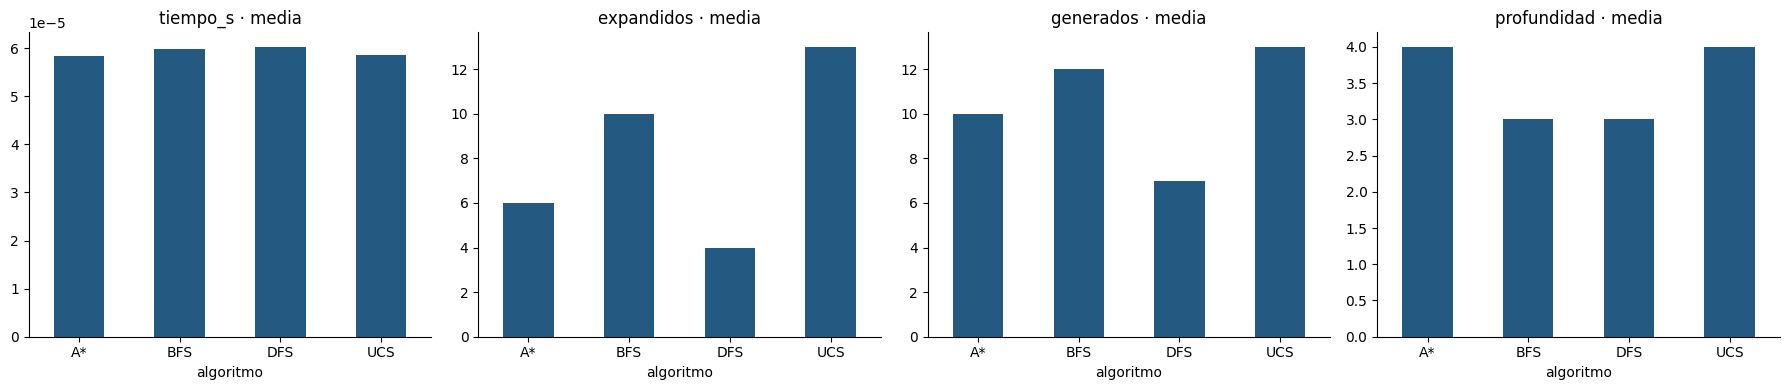


===== 8-PUZZLE =====


estado,exito
algoritmo,
A*,3
BFS,3
DFS,3
UCS,3


tiempo_s                                         costo             \
             count      mean       std       min       max count  mean  std   
algoritmo                                                                     
A*               3  0.000153  0.000031  0.000131  0.000188     3   4.0  0.0   
BFS              3  0.001617  0.002466  0.000185  0.004465     3   4.0  0.0   
DFS              3  0.135129  0.072458  0.091982  0.218783     3  24.0  0.0   
UCS              3  0.000233  0.000044  0.000205  0.000283     3   4.0  0.0   

                   ... frontera_max                    profundidad             \
          min max  ...        count  mean  std min max       count  mean  std   
algoritmo          ...                                                          
A*          4   4  ...            3   6.0  0.0   6   6           3   4.0  0.0   
BFS         4   4  ...            3  18.0  0.0  18  18           3   4.0  0.0   
DFS        24  24  ...            3  22.0  0.0  22  22           3  24.0  0.0   
UCS         4   4  ...            3  18.0  0.0  18  18           3   4.0  0.0   

                   
          min max  
algoritmo          
A*          4   4  
BFS         4   4  
DFS        24  24  
UCS         4   4  

[4 rows x 35 columns]

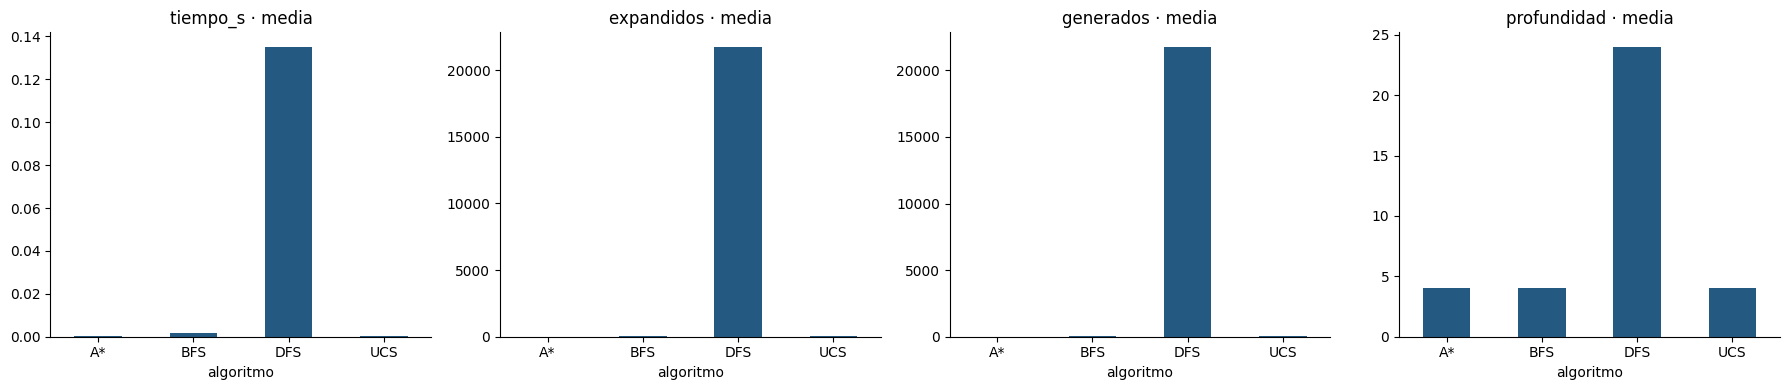


===== KNAPSACK =====


estado,exito
algoritmo,
A*,3
BFS,3
DFS,3
UCS,3


tiempo_s                                         costo             \
             count      mean       std       min       max count  mean  std   
algoritmo                                                                     
A*               3  0.000194  0.000045  0.000161  0.000245     3 -19.0  0.0   
BFS              3  0.000038  0.000018  0.000025  0.000058     3 -19.0  0.0   
DFS              3  0.000029  0.000009  0.000023  0.000040     3 -19.0  0.0   
UCS              3  0.000037  0.000010  0.000029  0.000047     3 -19.0  0.0   

                   ... frontera_max                   profundidad            \
          min max  ...        count mean  std min max       count mean  std   
algoritmo          ...                                                        
A*        -19 -19  ...            3  3.0  0.0   3   3           3  5.0  0.0   
BFS       -19 -19  ...            3  4.0  0.0   4   4           3  5.0  0.0   
DFS       -19 -19  ...            3  2.0  0.0   2   2           3  5.0  0.0   
UCS       -19 -19  ...            3  2.0  0.0   2   2           3  5.0  0.0   

                   
          min max  
algoritmo          
A*          5   5  
BFS         5   5  
DFS         5   5  
UCS         5   5  

[4 rows x 35 columns]

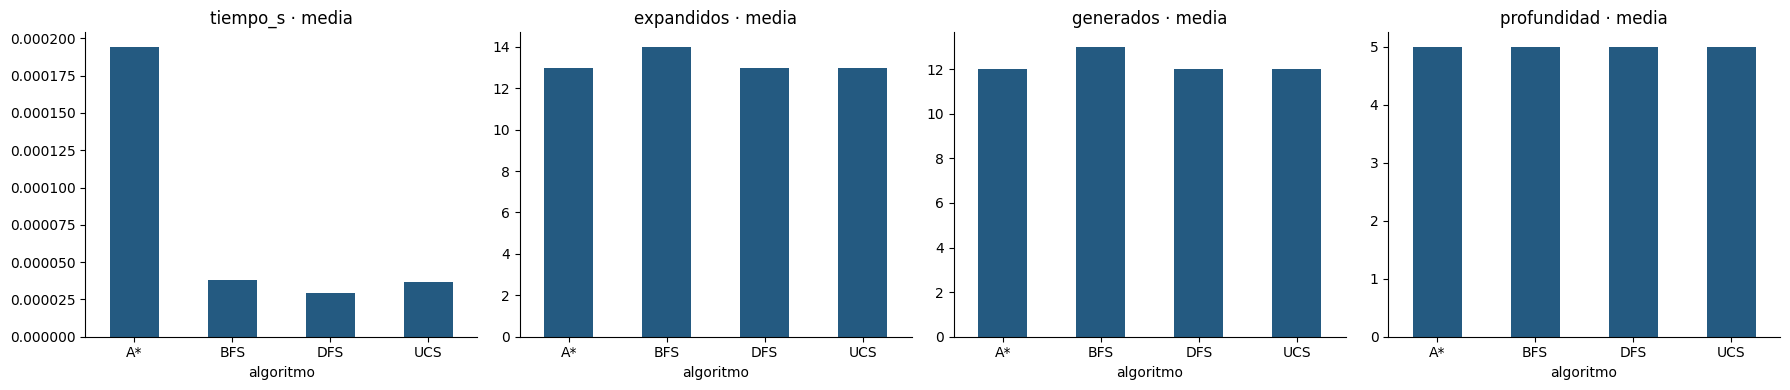

In [13]:
print('===== RUMANIA =====')
comparar('rumania', 'A→B', CONFIG_RUMANIA)

print('\n===== 8-PUZZLE =====')
comparar('8-puzzle', 'par_par', CONFIG_PUZZLE)

print('\n===== KNAPSACK =====')
comparar('knapsack', 'fila_0', CONFIG_KNAPSACK)

In [18]:


def serializable(obj):
    if isinstance(obj, np.ndarray): return obj.tolist()
    if isinstance(obj, np.generic): return obj.item()
    raise TypeError(f'Tipo no exportable: {type(obj).__name__}')


def exportar_zip():
    """Réplica exacta de la función del profesor: ZIP con CSV + JSON."""
    import zipfile
    carpeta = Path('evidencias_laboratorio'); carpeta.mkdir(exist_ok=True)

    # 1) Tabla de métricas a CSV
    tabla_resultados().to_csv(carpeta / 'metricas.csv', index=False)

    # 2) Evidencia completa a JSON
    evidencia = {
        'entorno': ENTORNO,
        'sha256_datos_knapsack': HUELLA_DATOS,
        'fuente': 'https://www.kaggle.com/datasets/warcoder/knapsack-problem',
        'archivo_fuente': 'knapsack_5_items.csv',
        'fila_knapsack': 0,
        'entrada_knapsack': ENTRADA_KNAPSACK,
        'registros': REGISTROS,
        'salidas': SALIDAS,
    }
    (carpeta / 'resultados.json').write_text(
        json.dumps(evidencia, default=serializable, ensure_ascii=False, indent=2),
        encoding='utf-8')

    # 3) Empaqueta ambos en un ZIP
    with zipfile.ZipFile('evidencias_laboratorio.zip', 'w', zipfile.ZIP_DEFLATED) as z:
        for nombre in ('metricas.csv', 'resultados.json'):
            z.write(carpeta / nombre, nombre)

    print(' evidencias_laboratorio.zip generado.')
    try:
        from google.colab import files
        files.download('evidencias_laboratorio.zip')
    except ImportError:
        pass


def exportar_xlsx():
    """Entregable: Excel con 4 hojas."""
    df = tabla_resultados()

    with pd.ExcelWriter('resultados.xlsx', engine='openpyxl') as w:
        # Hoja 1: resultados crudos
        df.to_excel(w, sheet_name='Resultados', index=False)

        # Hoja 2: resumen estadístico
        metricas = ['tiempo_s', 'costo', 'expandidos', 'generados',
                    'frontera_max', 'profundidad']
        ok = df[df.estado == 'exito'].copy()
        for c in metricas:
            ok[c] = pd.to_numeric(ok[c], errors='coerce')

        (ok.groupby(['problema', 'algoritmo'])[metricas]
           .agg(['mean', 'std', 'min', 'max'])
           .round(4)
           .to_excel(w, sheet_name='Resumen'))

        # Hoja 3: pivote de nodos expandidos
        (ok.pivot_table(index='algoritmo', columns='problema',
                        values='expandidos', aggfunc='mean')
           .round(2)
           .to_excel(w, sheet_name='Comparativa_expandidos'))

        # Hoja 4: crosstab de estados
        pd.crosstab([df.problema, df.algoritmo], df.estado)\
          .to_excel(w, sheet_name='Estados')

    print(' resultados.xlsx generado con 4 hojas.')
    try:
        from google.colab import files
        files.download('resultados.xlsx')
    except ImportError:
        pass

exportar_zip()
exportar_xlsx()

 evidencias_laboratorio.zip generado.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 resultados.xlsx generado con 4 hojas.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 7. 📝 Interpretación de resultados

**1. ¿Cómo justificas tu modelación y cómo comprobaste la validez de las soluciones?**
Cada problema se modeló con estado, acciones, costos y objetivo explícitos. Los algoritmos verifican la igualdad exacta con el estado objetivo y, para Rumania, la ruta devuelta se contrasta visualmente contra `ROADS`.

**2. Diferencias entre BFS, DFS, UCS y A\*.**
- **BFS:** explora por niveles, óptimo solo con costo uniforme, consume mucha memoria y conviene si buscas la cantidad minima de pasos.
- **DFS:** explora en profundidad y usa poca memoria.
- **UCS:** óptimo en cualquier grafo con costos no negativos, ordena la frontera por costo acumulado.
- **A\*:** óptimo con heurística admisible y reduce los nodos expandidos.

**3. Costos, heurística y manejo de repetidos.**
En Rumania, BFS encontró una ruta con menos saltos pero no la más corta en km; UCS y A\* coincidieron en la óptima. La heurística redujo los nodos expandidos. El manejo de repetidos con diccionario de mejor costo es indispensable  para evitar expansiones repetidas.

**4. Ejecuciones que terminaron por límite.**
DFS en el 8-Puzzle alcanzó el límite de profundidad en algunos casos (no encontramos solución dentro del presupuesto). De un límite no se puede concluir que no exista solución; solo que no se encontró dentro del presupuesto.

**5. Limitaciones y reproducibilidad.**
Las mediciones de tiempo dependen del hardware. La memoria opcional se mide con `tracemalloc`, no es la RAM total. La reproducibilidad está garantizada por la semilla y por la exportación del `resultados.xlsx`.

**6. Evidencia de optimalidad.**
UCS y A* coincidieron en la ruta óptima de Rumania (A→S→R→P→B, 418 km) y en el costo del 8-Puzzle. A* expande menos nodos porque utiliza información heurística admisible.

**Conclusiones del equipo.**
No existe un algoritmo universalmente mejor; la elección depende de la estructura del problema, los costos y la información disponible. A* destacó cuando se dispone de una buena heurística; UCS fue consistente cuando los costos importan; BFS fue útil solo con costos uniformes; DFS tiene falta de optimalidad. La actividad demuestra que modelar correctamente el problema es tan importante como elegir el algoritmo.

Rumania (A*): Arad → Sibiu → Rimnicu Vilcea → Pitesti → Bucarest


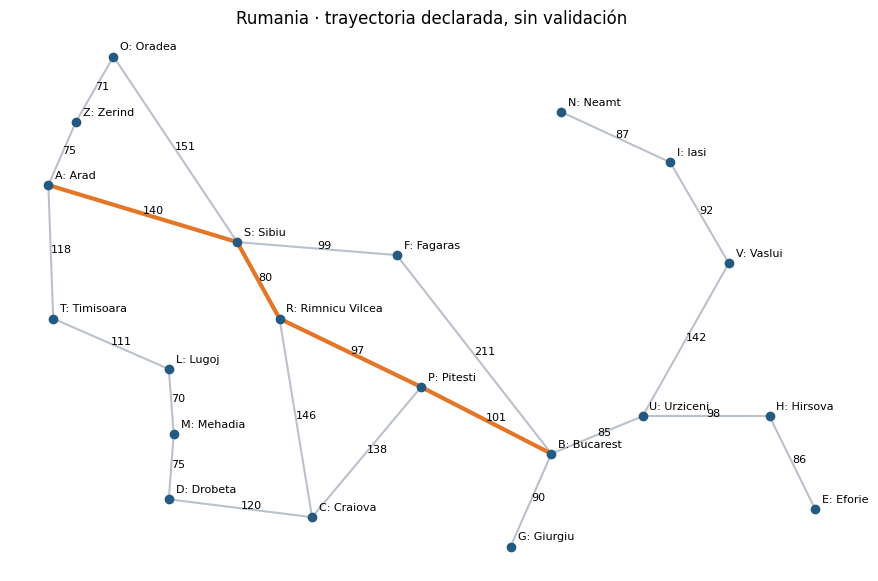

Rumania (A*): Arad → Sibiu → Rimnicu Vilcea → Pitesti → Bucarest


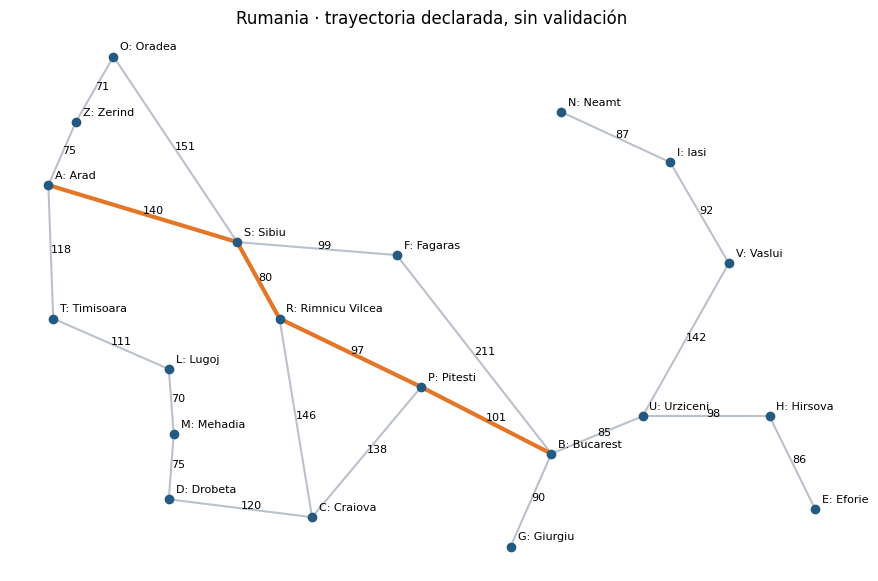

Rumania (A*): Arad → Sibiu → Rimnicu Vilcea → Pitesti → Bucarest


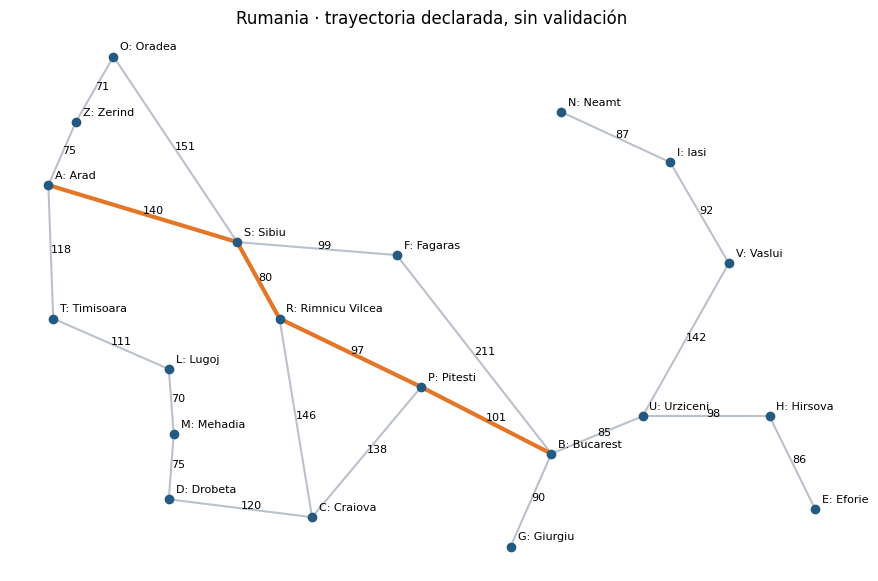

8-Puzzle (A*): 4 movimientos


interactive(children=(IntSlider(value=0, description='paso', max=4), Output()), _dom_classes=('widget-interact…

8-Puzzle (A*): 4 movimientos


interactive(children=(IntSlider(value=0, description='paso', max=4), Output()), _dom_classes=('widget-interact…

8-Puzzle (A*): 4 movimientos


interactive(children=(IntSlider(value=0, description='paso', max=4), Output()), _dom_classes=('widget-interact…

Knapsack (A*) selección: [1]


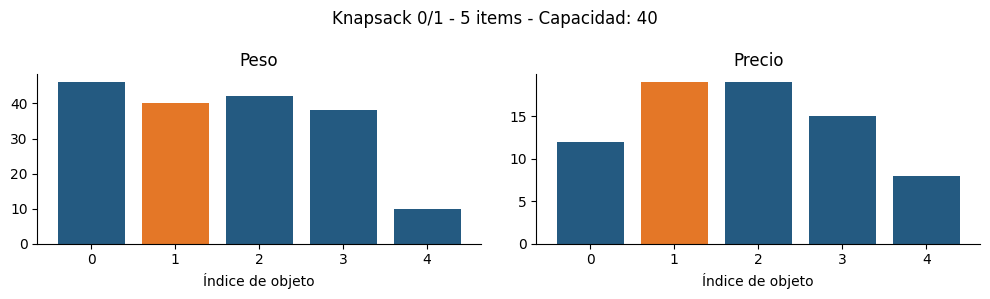

Knapsack (A*) selección: [1]


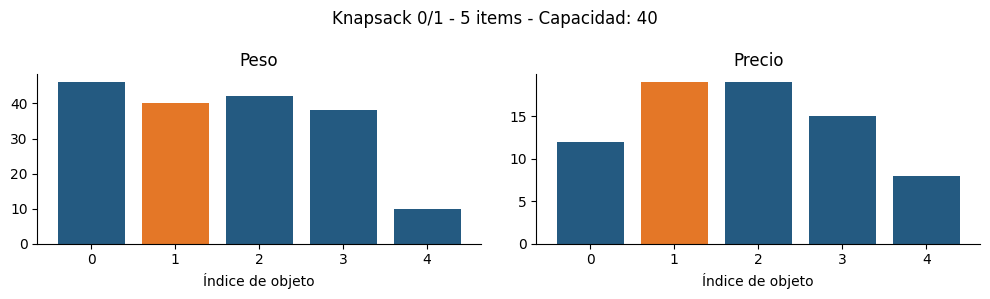

Knapsack (A*) selección: [1]


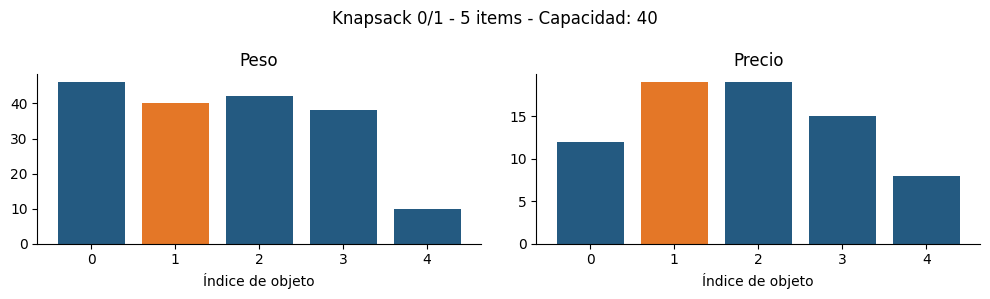

In [15]:
# Muestra la ruta ganadora de A* en Rumania y los tableros del 8-Puzzle con A*
for rid, salida in SALIDAS.items():
    reg = REGISTROS[rid]
    if reg['estado'] != 'exito':
        continue
    visual = salida.get('visual', {})
    if reg['problema'] == 'rumania' and 'ruta' in visual and reg['algoritmo'] == 'A*':
        print('Rumania (A*):', ' → '.join(NAMES[c] for c in visual['ruta']))
        ver_rumania(visual['ruta'])
    if reg['problema'] == '8-puzzle' and 'tableros' in visual and reg['algoritmo'] == 'A*':
        print(f"8-Puzzle (A*): {len(visual['tableros'])-1} movimientos")
        explorar_tableros(visual['tableros'])
    if reg['problema'] == 'knapsack' and 'seleccion' in visual and reg['algoritmo'] == 'A*':
        print('Knapsack (A*) selección:', visual['seleccion'])
        ver_knapsack(ENTRADA_KNAPSACK, visual['seleccion'])